# Data exploration - P2!

In [2]:
# Load used packages
import pandas as pd
import matplotlib.pyplot as mp
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


Goal 1: Load in the data

In [3]:
base_path = "/mnt/c/Users/amineeva/OneDrive - Olin College of Engineering/2025-2026/Semester 2/Scientific Computing/Project 2 - Asteroids/"
asteroid_data_output_path = base_path + "Synthetic_Proper_Elements_Hirayama_full_dataset.csv"

df = pd.read_csv(asteroid_data_output_path)
print(df.head())

  Name   mag      a_AU         e     sin_I  n_deg_per_yr  g_arcsec_per_yr  \
0    1  3.41  2.767096  0.116198  0.167585     78.193318        54.070272   
1    2  4.17  2.770918  0.281258  0.547547     78.041654        -1.335344   
2    3  5.36  2.669366  0.233506  0.229226     82.528181        43.635655   
3    4  3.31  2.361513  0.098758  0.111336     99.188833        36.872897   
4    6  5.76  2.425271  0.158486  0.247863     95.303184        31.568209   

   s_arcsec_per_yr  LCEx1E6  My  
0       -59.170034     1.16  -2  
1       -46.393342    44.20  10  
2       -61.222138    13.74  -2  
3       -39.597863     2.83   2  
4       -41.829042     4.56   2  


/tmp/ipykernel_389092/98963781.py:4: DtypeWarning: Columns (0: Name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(asteroid_data_output_path)


Goal 1.5: Add an 'i' column

In [4]:
I_radians = np.arcsin(df['sin_I'])
I_degrees = np.degrees(I_radians)

Goal 2: Create a vs. i and e vs. i plots of the loaded data

Index(['Name', 'mag', 'a_AU', 'e', 'sin_I', 'n_deg_per_yr', 'g_arcsec_per_yr',
       's_arcsec_per_yr', 'LCEx1E6', 'My'],
      dtype='str')


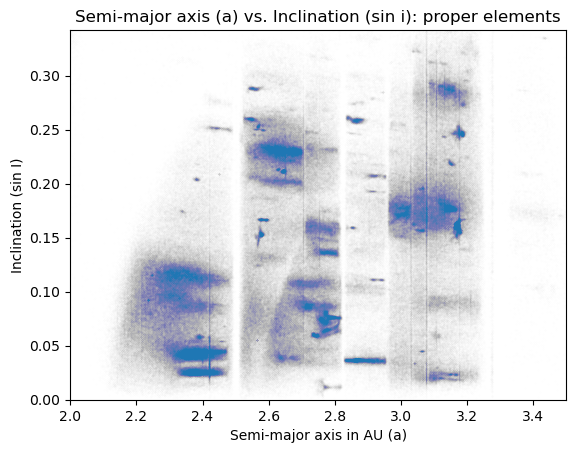

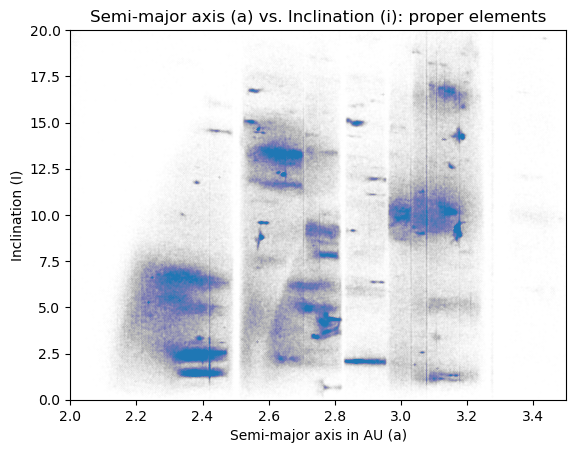

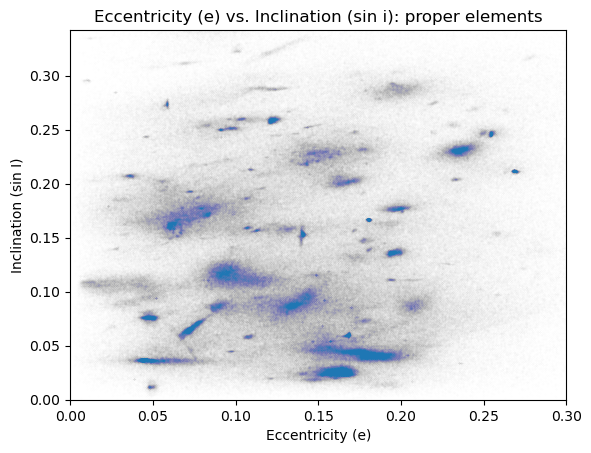

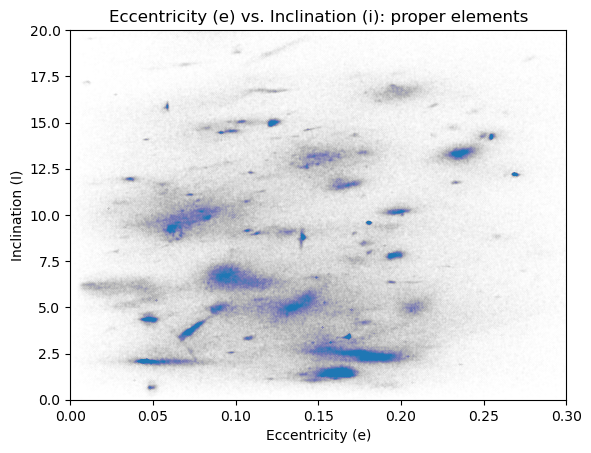

In [5]:
print(df.columns)

mp.figure()
mp.scatter(df['a_AU'], df['sin_I'], s = 0.1, alpha = 0.01)
mp.ylabel("Inclination (sin I)")
mp.xlabel("Semi-major axis in AU (a)")
mp.xlim(2, 3.5)
mp.ylim(0, np.sin(np.radians(20)))
mp.title("Semi-major axis (a) vs. Inclination (sin i): proper elements")
mp.show()

mp.figure()
mp.scatter(df['a_AU'], I_degrees, s = 0.1, alpha = 0.01)
mp.ylabel("Inclination (I)")
mp.xlabel("Semi-major axis in AU (a)")
mp.xlim(2, 3.5)
mp.ylim(0, 20)
mp.title("Semi-major axis (a) vs. Inclination (i): proper elements")
mp.show()


mp.figure()
mp.scatter(df['e'], df['sin_I'], s = 0.1, alpha = 0.01)
mp.ylabel("Inclination (sin I)")
mp.xlabel("Eccentricity (e)")
mp.xlim(0, 0.3)
mp.ylim(0, np.sin(np.radians(20)))
mp.title("Eccentricity (e) vs. Inclination (sin i): proper elements")
mp.show()

mp.figure()
mp.scatter(df['e'], I_degrees, s = 0.1, alpha = 0.01)
mp.ylabel("Inclination (I)")
mp.xlabel("Eccentricity (e)")
mp.xlim(0, 0.3)
mp.ylim(0, 20)
mp.title("Eccentricity (e) vs. Inclination (i): proper elements")
mp.show()





Here are the plots for a vs. I (1) and  vs. I (2). I'm not sure how to deal with the sin? I don't really understand why the inclination is sin i, and how to convert that back to just 'i' so I can look at the families

### Playing around with a 3D plot to identify clusters visibly

In [ ]:
fig = mp.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['a_AU'],
    df['e'],
    df['sin_I'],
    s=0.01,
    alpha=0.01
)

ax.set_xlabel('a')
ax.set_ylabel('e')
ax.set_zlabel('sin(i)')

ax.set_xlim(2, 3.5)
ax.set_ylim(0, 0.3)
ax.set_zlim(0, np.sin(np.radians(20)))

fig.subplots_adjust(right=0.4)

ax.set_title('Proper Element Space (a, e, sin(i))')

mp.show()


fig = mp.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['a_AU'],
    df['e'],
    df['sin_I'],
    s=0.01,
    alpha=0.01
)

ax.set_xlabel('a')
ax.set_ylabel('e')
ax.set_zlabel('sin(i)')

ax.set_xlim(2, 3.5)
ax.set_ylim(0, 0.3)
ax.set_zlim(0, np.sin(np.radians(20)))

fig.subplots_adjust(right=0.4)

ax.set_title('Proper Element Space (a, e, sin(i))')

mp.show()

### Machine learning method 1: HCM


Okay so scikit-learn doesn't actually have the version that the AstDys group uses -> they use a specialized form of a distance clustering algorithm
- using scikit-learn's agglomerative heirarchical clustering
- got this error: MemoryError: Unable to allocate 4.83 TiB for an array with shape (663791061528,) and data type float64
    - because this is huge, I'm going to run this on multiple split datasets

In [5]:
from sklearn import cluster
from sklearn.preprocessing import StandardScaler, normalize


In [6]:
# getting the data
X = df[['a_AU','e','sin_I']].values

sin5 = np.sin(np.radians(5))

subset = df[
    (df['a_AU'] > 2.8) &
    (df['a_AU'] < 3.0) &
    (df['sin_I'] >= 0) &
    (df['sin_I'] <= sin5)
]


X = subset[['a_AU','e','sin_I']].values

len(X)

# first step, scaling -> makes all the features comparabl because clustering depends on distance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# normialization also helps? -> need to understand why
model = cluster.AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

labels = model.fit_predict(X_scaled)

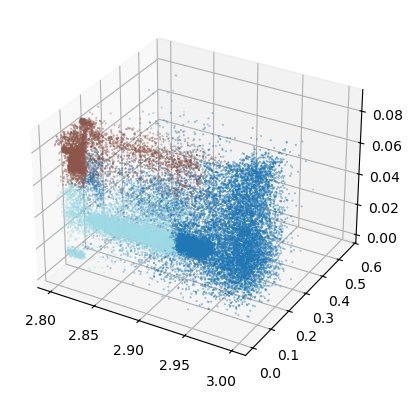

In [12]:
fig = mp.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    subset['a_AU'],
    subset['e'],
    subset['sin_I'],
    c=labels,
    s=0.1,
    cmap='tab20'
)

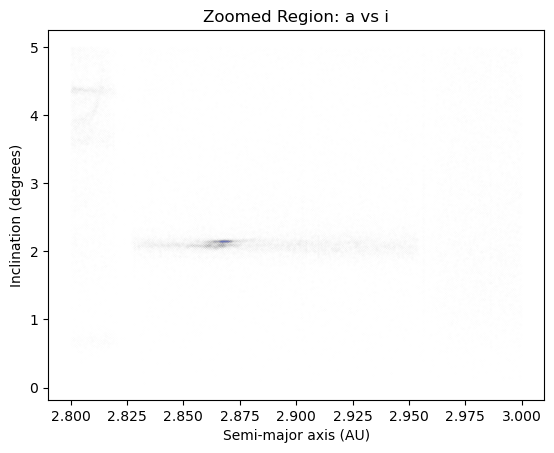

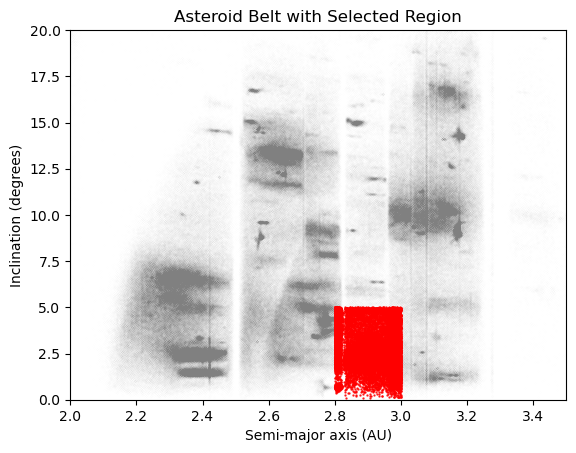

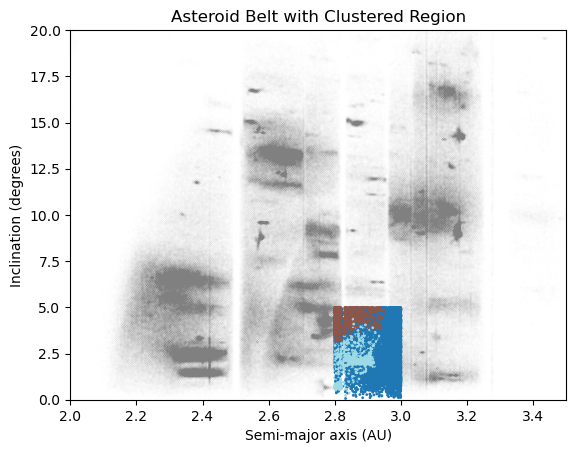

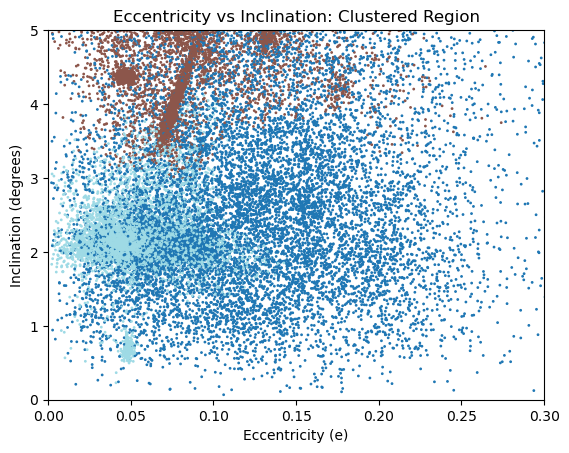

In [7]:
I_degrees = np.degrees(np.arcsin(df['sin_I']))
subset_I_degrees = np.degrees(np.arcsin(subset['sin_I']))
mp.figure()

mp.scatter(
    subset['a_AU'],
    subset_I_degrees,
    s=0.05,
    alpha=0.01
)

mp.xlabel("Semi-major axis (AU)")
mp.ylabel("Inclination (degrees)")
mp.title("Zoomed Region: a vs i")

mp.show()


mp.figure()

# background asteroids
mp.scatter(
    df['a_AU'],
    I_degrees,
    s=0.05,
    alpha=0.01,
    color='gray'
)

# highlighted subset
mp.scatter(
    subset['a_AU'],
    subset_I_degrees,
    s=0.5,
    alpha=0.8,
    color='red'
)

mp.xlabel("Semi-major axis (AU)")
mp.ylabel("Inclination (degrees)")
mp.xlim(2,3.5)
mp.ylim(0,20)

mp.title("Asteroid Belt with Selected Region")

mp.show()


mp.figure()

# background: all asteroids
mp.scatter(
    df['a_AU'],
    I_degrees,
    s=0.05,
    alpha=0.01,
    color='gray'
)

# clustered subset (colored by labels)
mp.scatter(
    subset['a_AU'],
    subset_I_degrees,
    c=labels,
    s=1,
    cmap='tab20'
)

mp.xlabel("Semi-major axis (AU)")
mp.ylabel("Inclination (degrees)")
mp.xlim(2, 3.5)
mp.ylim(0, 20)

mp.title("Asteroid Belt with Clustered Region")

mp.show()

mp.figure()

# Background: all asteroids in gray
mp.scatter(
    df['e'],
    I_degrees,
    s=0.03,        # make background points small
    alpha=0.005,   # faint so clusters pop
    color='gray'
)

# Clustered subset, colored by labels
mp.scatter(
    subset['e'],
    subset_I_degrees,
    c=labels,
    s=1,           # larger points for visibility
    cmap='tab20'
)

mp.xlabel("Eccentricity (e)")
mp.ylabel("Inclination (degrees)")
mp.xlim(0, 0.3)
mp.ylim(0, 5.0)

mp.title("Eccentricity vs Inclination: Clustered Region")

mp.show()

### Reflection
At this point, here are my thoughts:
- I chose n_clusters somewhat arbitrarily? Set to 8 right now, but this could be lower?
- Chose 'ward' as the linkage type -> merges based on minimal total variance, which means that it locks in on spherical clusters, which I don't think works for the linearly spread example I chose to go with -> try single?

-> from Carter Harris: after running it once, see how close the clusters are and if they're closer than a value I choose, it would change the number of clusters until 

In [1]:
X = df[['a_AU','e','sin_I']].values

sin5 = np.sin(np.radians(5))

subset = df[
    (df['a_AU'] > 2.8) &
    (df['a_AU'] < 3.0) &
    (df['sin_I'] >= 0) &
    (df['sin_I'] <= sin5)
]


X = subset[['a_AU','e','sin_I']].values

len(X)

# first step, scaling -> makes all the features comparabl because clustering depends on distance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# normialization also helps? -> need to understand why
model = cluster.AgglomerativeClustering(
    n_clusters=8,
    linkage='complete'
)

labels = model.fit_predict(X_scaled)

# 3D model of labeled points
fig = mp.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    subset['a_AU'],
    subset['e'],
    subset['sin_I'],
    c=labels,
    s=0.1,
    cmap='tab20'
)

I_degrees = np.degrees(np.arcsin(df['sin_I']))
subset_I_degrees = np.degrees(np.arcsin(subset['sin_I']))
mp.figure()

mp.scatter(
    subset['a_AU'],
    subset_I_degrees,
    s=0.05,
    alpha=0.01
)

mp.xlabel("Semi-major axis (AU)")
mp.ylabel("Inclination (degrees)")
mp.title("Zoomed Region: a vs i")

mp.show()


mp.figure()

# background asteroids
mp.scatter(
    df['a_AU'],
    I_degrees,
    s=0.05,
    alpha=0.01,
    color='gray'
)

# highlighted subset
mp.scatter(
    subset['a_AU'],
    subset_I_degrees,
    s=0.5,
    alpha=0.8,
    color='red'
)

mp.xlabel("Semi-major axis (AU)")
mp.ylabel("Inclination (degrees)")
mp.xlim(2,3.5)
mp.ylim(0,20)

mp.title("Asteroid Belt with Selected Region")

mp.show()


mp.figure()

# background: all asteroids
mp.scatter(
    df['a_AU'],
    I_degrees,
    s=0.05,
    alpha=0.01,
    color='gray'
)

# clustered subset (colored by labels)
mp.scatter(
    subset['a_AU'],
    subset_I_degrees,
    c=labels,
    s=1,
    cmap='tab20'
)

mp.xlabel("Semi-major axis (AU)")
mp.ylabel("Inclination (degrees)")
mp.xlim(2, 3.5)
mp.ylim(0, 20)

mp.title("Asteroid Belt with Clustered Region")

mp.show()

mp.figure()

# Background: all asteroids in gray
mp.scatter(
    df['e'],
    I_degrees,
    s=0.03,        # make background points small
    alpha=0.005,   # faint so clusters pop
    color='gray'
)

# Clustered subset, colored by labels
mp.scatter(
    subset['e'],
    subset_I_degrees,
    c=labels,
    s=1,           # larger points for visibility
    cmap='tab20'
)

mp.xlabel("Eccentricity (e)")
mp.ylabel("Inclination (degrees)")
mp.xlim(0, 0.3)
mp.ylim(0, 5.0)

mp.title("Eccentricity vs Inclination: Clustered Region")

mp.show()

NameError: name 'df' is not defined

### Comparing known with clustering results

In [ ]:
base_path = "/mnt/c/Users/amineeva/OneDrive - Olin College of Engineering/2025-2026/Semester 2/Scientific Computing/Project 2 - Asteroids/"
asteroid_validation_data = base_path + "all_tro.members.txt"

df_validation = pd.read_csv(asteroid_validation_data)
print(df_validation.head())

### Mid-Project Code Review:

Next steps;